(120, 160) uint8


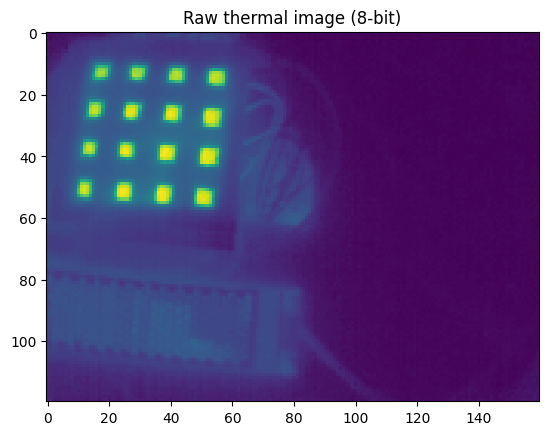

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

folder = "/home/aayushi/exodia/Pictures/lepton"

img_path = sorted(glob.glob(folder + "/*.tiff"))[0]

img8 = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

img8 = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)

print(img8.shape, img8.dtype)

plt.imshow(img8)
plt.title("Raw thermal image (8-bit)")
plt.show()


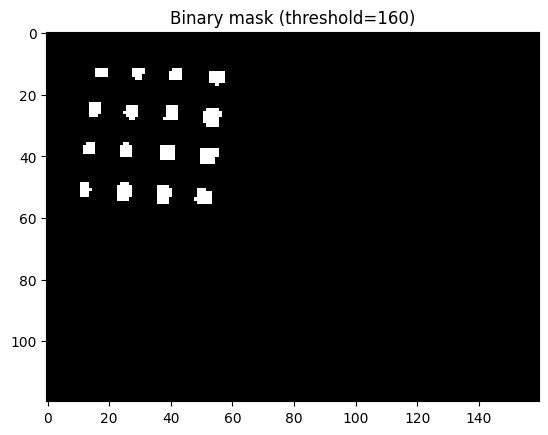

In [31]:
THRESH = 160  # <-- tune this

_, binary = cv2.threshold(img8, THRESH, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.title(f"Binary mask (threshold={THRESH})")
plt.show()


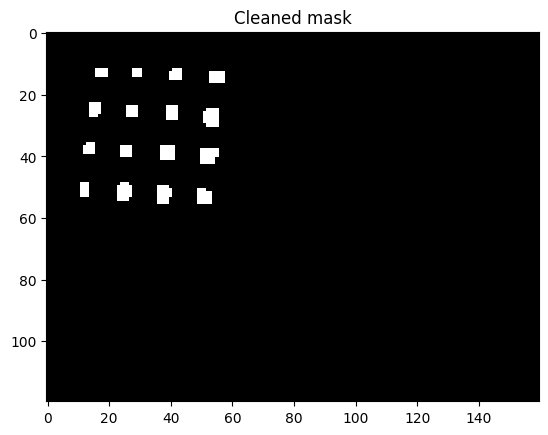

In [32]:
kernel = np.ones((3,3), np.uint8)

binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

plt.imshow(binary, cmap='gray')
plt.title("Cleaned mask")
plt.show()


In [33]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)

# ignore background label 0
centroids = centroids[1:]
areas = stats[1:, cv2.CC_STAT_AREA]

print("Detected blobs:", len(centroids))


Detected blobs: 16


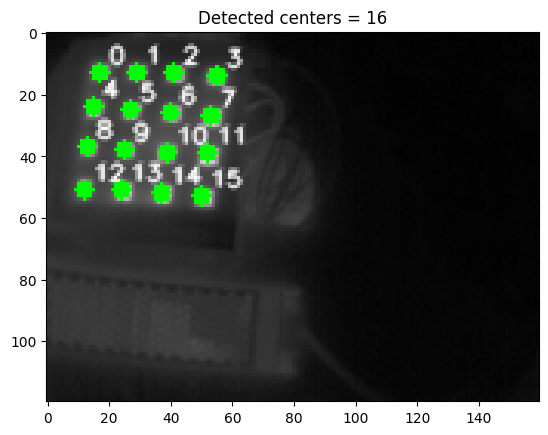

In [34]:
vis = cv2.cvtColor(img8, cv2.COLOR_GRAY2BGR)

for i,c in enumerate(centroids):
    x, y = int(c[0]), int(c[1])
    cv2.circle(vis, (x,y), 3, (0,255,0), -1)
    cv2.putText(
        vis,
        str(i),
        (x+3, y-3),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.25,
        (255,255,255),
        1,
        cv2.LINE_AA
    )

plt.imshow(vis)
plt.title(f"Detected centers = {len(centroids)}")
plt.show()


Total images: 40

Threshold performance:
Threshold  50 | perfect=0/40
Threshold  55 | perfect=0/40
Threshold  60 | perfect=0/40
Threshold  65 | perfect=0/40
Threshold  70 | perfect=0/40
Threshold  75 | perfect=0/40
Threshold  80 | perfect=2/40
Threshold  85 | perfect=3/40
Threshold  90 | perfect=6/40
Threshold  95 | perfect=7/40
Threshold 100 | perfect=9/40
Threshold 105 | perfect=9/40
Threshold 110 | perfect=17/40
Threshold 115 | perfect=31/40
Threshold 120 | perfect=40/40
Threshold 125 | perfect=40/40
Threshold 130 | perfect=40/40
Threshold 135 | perfect=40/40
Threshold 140 | perfect=40/40
Threshold 145 | perfect=40/40
Threshold 150 | perfect=40/40
Threshold 155 | perfect=40/40
Threshold 160 | perfect=40/40
Threshold 165 | perfect=40/40
Threshold 170 | perfect=40/40
Threshold 175 | perfect=35/40
Threshold 180 | perfect=33/40
Threshold 185 | perfect=30/40
Threshold 190 | perfect=24/40
Threshold 195 | perfect=11/40
Threshold 200 | perfect=0/40
Threshold 205 | perfect=0/40
Threshold 210

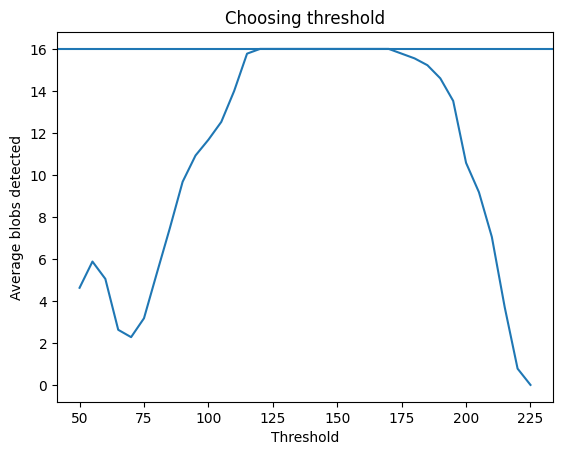

In [43]:
import cv2
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

folder = "/home/aayushi/exodia/Pictures/lepton"
#folder = "/home/aayushi/Documents/Lepton/camera2_mask"
image_paths = sorted(glob.glob(folder + "/*.tiff"))

print("Total images:", len(image_paths))

# thresholds to test
thresholds = range(50, 230, 5)

results = {}

kernel = np.ones((3,3), np.uint8)

for t in thresholds:

    counts = []

    for path in image_paths:

        img8 = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        img8 = cv2.cvtColor(img8, cv2.COLOR_RGB2GRAY)
        img8 = np.uint8(img8)

        _, binary = cv2.threshold(img8, t, 255, cv2.THRESH_BINARY)

        # clean noise
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

        num_labels, _, _, _ = cv2.connectedComponentsWithStats(binary)

        counts.append(num_labels - 1)

    results[t] = counts


# print summary
print("\nThreshold performance:")
for t in thresholds:
    arr = np.array(results[t])

    print(
        f"Threshold {t:3d} | "
        f"perfect={(arr==16).sum()}/{len(arr)}"
    )


# plot how blob count changes with threshold
means = [np.mean(results[t]) for t in thresholds]

plt.figure()
plt.plot(list(thresholds), means)
plt.axhline(16)
plt.xlabel("Threshold")
plt.ylabel("Average blobs detected")
plt.title("Choosing threshold")
plt.show()


In [42]:
import cv2
import numpy as np
import glob
import os

folder = "/home/aayushi/exodia/Pictures/brick1"
THRESH =160
rows, cols = 4, 4
spacing = 20/7      # mm

kernel = np.ones((3,3), np.uint8)

# 4x4 planar grid
objp = np.zeros((rows*cols, 3), np.float32)

objp[:, :2] = np.mgrid[
    0:cols,
    0:rows
].T.reshape(-1,2) * spacing

objpoints = []   # 3D points
imgpoints = []   # 2D points

def order_points_grid_diagonal(pts, rows=4, cols=4):

    pts = np.array(pts)

    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).flatten()

    TL = pts[np.argmin(s)]
    BR = pts[np.argmax(s)]

    TR = pts[np.argmin(diff)]
    BL = pts[np.argmax(diff)]

    vx = TR - TL
    vy = BL - TL

    vx = vx / np.linalg.norm(vx)
    vy = vy / np.linalg.norm(vy)

    coords = []

    for p in pts:

        v = p - TL

        x = np.dot(v, vx)
        y = np.dot(v, vy)

        coords.append([x,y])

    coords = np.array(coords)

    order = np.lexsort((coords[:,0], coords[:,1]))

    pts_sorted = pts[order]

    ordered = []

    for r in range(rows):
        row_pts = pts_sorted[r*cols:(r+1)*cols]
        row_pts = row_pts[np.argsort(row_pts[:,0])]
        ordered.append(row_pts)

    return np.vstack(ordered)


image_paths = sorted(glob.glob(folder + "/*.tiff"))

for idx,path in enumerate(image_paths):

    img16 = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    img8 = cv2.cvtColor(img16, cv2.COLOR_RGB2GRAY)
    img8 = np.uint8(img8)

    _, binary = cv2.threshold(img8, THRESH, 255, cv2.THRESH_BINARY)

    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary)

    if num_labels-1 != 16:
        print("Skipping:", path)
        continue

    pts = centroids[1:]   # remove background
    vis = cv2.cvtColor(img8, cv2.COLOR_GRAY2BGR)
    pts=order_points_grid_diagonal(pts)
    for i,c in enumerate(pts):
        x, y = int(c[0]), int(c[1])
        cv2.circle(vis, (x,y), 1, (255,0,0), -1)
        cv2.putText(
            vis,
            str(i),
            (x+3, y-3),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.25,
            (255,255,255),
            1,
            cv2.LINE_AA
        )

    plt.imshow(vis)
    plt.title(f"Image = {image_paths[idx]}")
    plt.show()
    

    objpoints.append(objp)
    imgpoints.append(pts.astype(np.float32))


print("Images used:", len(objpoints))

h, w = img8.shape

ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints,
    imgpoints,
    (w, h),
    None,
    None
)

print("\nCamera matrix:\n", K)
print("\nDistortion:\n", dist)
print("\nReprojection error:", ret)


Skipping: /home/aayushi/exodia/Pictures/brick1/cap_00.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_01.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_02.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_03.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_04.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_05.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_06.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_07.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_08.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_09.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_10.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_11.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_12.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_13.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_14.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_15.tiff
Skipping: /home/aayushi/exodia/Pictures/brick1/cap_16.ti

error: OpenCV(4.13.0) /io/opencv/modules/calib3d/src/calibration.cpp:1382: error: (-215:Assertion failed) nimages > 0 in function 'calibrateCameraRO'
